In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/home/anthony/cs285-rl/hw3"

In [2]:
def read_log_csv(run_dir, metrics=("Eval_AverageReturn",)):
    """Read step and specified metrics from a log.csv file."""
    path = f"{BASE_DIR}/{run_dir}/log.csv"
    df = pd.read_csv(path)
    df = df.dropna(subset=list(metrics))
    result = {"steps": df["step"].tolist()}
    for m in metrics:
        result[m] = df[m].tolist()
    return result

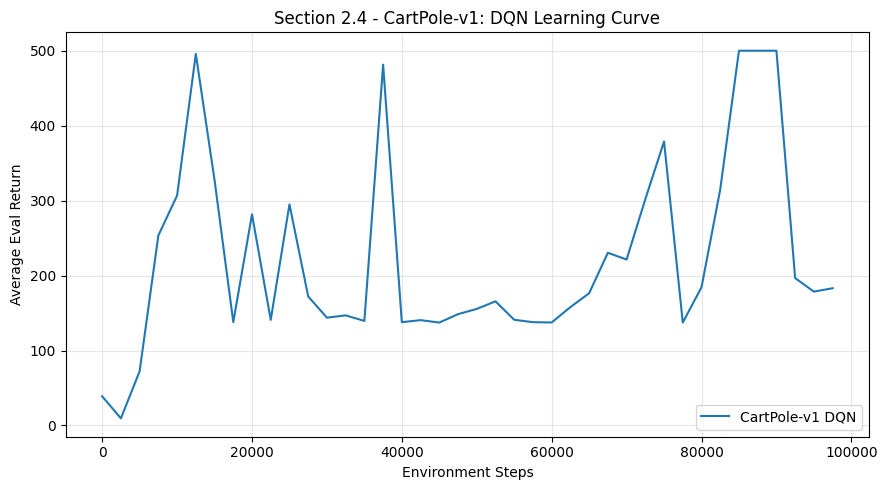

In [3]:
# Section 2.4 - CartPole DQN
cartpole_experiments = {
    "CartPole-v1 DQN": "exp/CartPole-v1_dqn_sd1_20260312_001126",
}

fig, ax = plt.subplots(figsize=(9, 5))

for name, path in cartpole_experiments.items():
    data = read_log_csv(path, metrics=("Eval_AverageReturn",))
    ax.plot(data["steps"], data["Eval_AverageReturn"], label=name)

ax.set_xlabel("Environment Steps")
ax.set_ylabel("Average Eval Return")
ax.set_title("Section 2.4 - CartPole-v1: DQN Learning Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

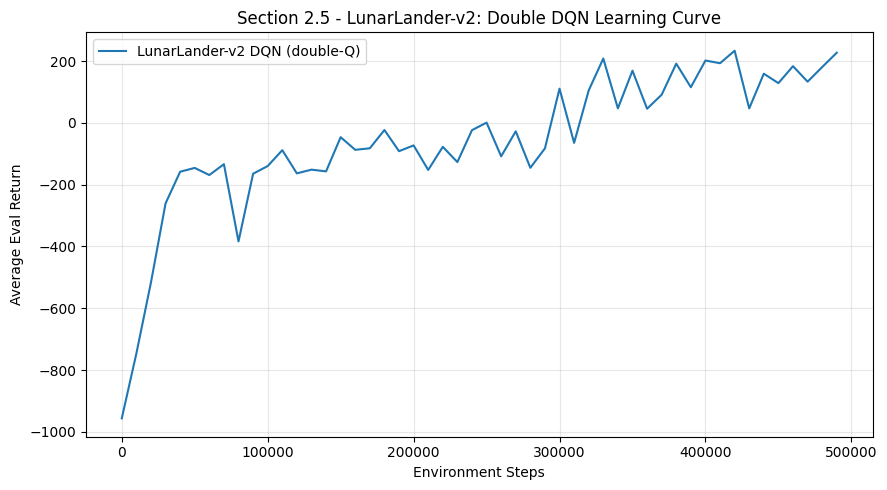

In [4]:
# Section 2.5 - LunarLander Double DQN
lunarlander_experiments = {
    "LunarLander-v2 DQN (double-Q)": "exp/LunarLander-v2_dqn_sd1_20260312_012734",
}

fig, ax = plt.subplots(figsize=(9, 5))

for name, path in lunarlander_experiments.items():
    data = read_log_csv(path, metrics=("Eval_AverageReturn",))
    ax.plot(data["steps"], data["Eval_AverageReturn"], label=name)

ax.set_xlabel("Environment Steps")
ax.set_ylabel("Average Eval Return")
ax.set_title("Section 2.5 - LunarLander-v2: Double DQN Learning Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

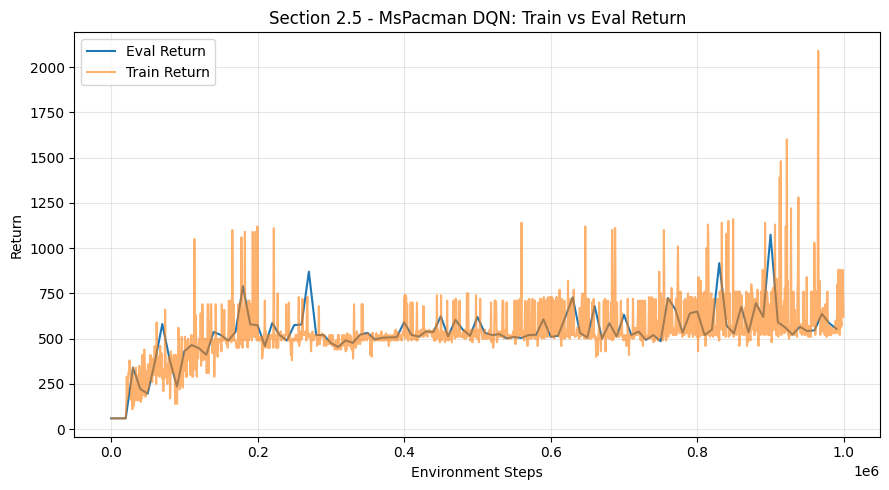

In [5]:
# MsPacman - Train vs Eval Return
run_dir = "exp/MsPacman_dqn_sd1_20260312_023038"

eval_data  = read_log_csv(run_dir, metrics=("Eval_AverageReturn",))
train_data = read_log_csv(run_dir, metrics=("Train_EpisodeReturn",))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(eval_data["steps"],  eval_data["Eval_AverageReturn"],   label="Eval Return")
ax.plot(train_data["steps"], train_data["Train_EpisodeReturn"], label="Train Return", alpha=0.6)

ax.set_xlabel("Environment Steps")
ax.set_ylabel("Return")
ax.set_title("Section 2.5 - MsPacman DQN: Train vs Eval Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

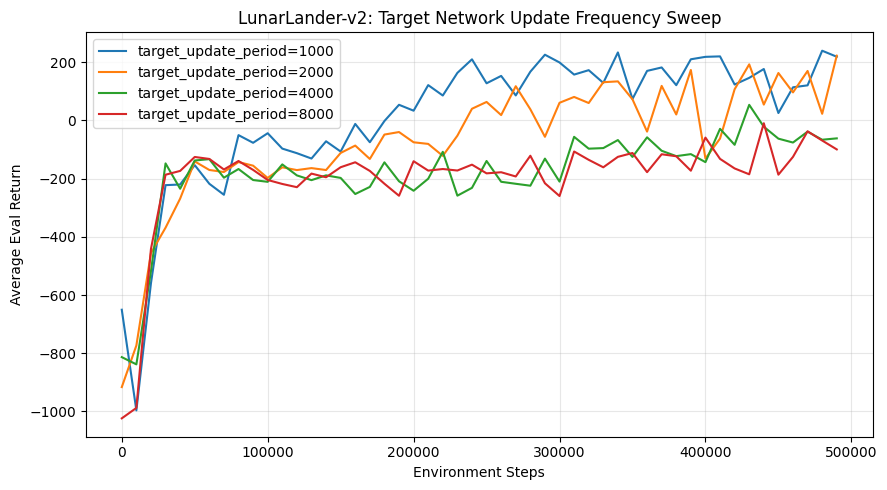

In [6]:
# Target update period sweep - LunarLander
tup_experiments = {
    "target_update_period=1000": "exp/LunarLander-v2_dqn_tup1000_sd1_20260312_031349",
    "target_update_period=2000": "exp/LunarLander-v2_dqn_tup2000_sd1_20260312_040638",
    "target_update_period=4000": "exp/LunarLander-v2_dqn_tup4000_sd1_20260312_050107",
    "target_update_period=8000": "exp/LunarLander-v2_dqn_tup8000_sd1_20260312_055518",
}

fig, ax = plt.subplots(figsize=(9, 5))

for name, path in tup_experiments.items():
    data = read_log_csv(path, metrics=("Eval_AverageReturn",))
    ax.plot(data["steps"], data["Eval_AverageReturn"], label=name)

ax.set_xlabel("Environment Steps")
ax.set_ylabel("Average Eval Return")
ax.set_title("LunarLander-v2: Target Network Update Frequency Sweep")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# HalfCheetah SAC
fig, ax = plt.subplots(figsize=(9, 5))

data = read_log_csv("exp/HalfCheetah-v4_sac_sd1_20260312_114831", metrics=("Eval_AverageReturn",))
ax.plot(data["steps"], data["Eval_AverageReturn"])

ax.set_xlabel("Environment Steps")
ax.set_ylabel("Average Eval Return")
ax.set_title("HalfCheetah-v4 SAC: Eval Return")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# HalfCheetah SAC: fixed vs auto-tuned temperature
fixed_data    = read_log_csv("exp/HalfCheetah-v4_sac_sd1_20260312_114831",          metrics=("Eval_AverageReturn",))
autotune_data = read_log_csv("exp/HalfCheetah-v4_sac_autotune_sd1_20260312_124357", metrics=("Eval_AverageReturn",))
alpha_data    = read_log_csv("exp/HalfCheetah-v4_sac_autotune_sd1_20260312_124357", metrics=("alpha",))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Eval return comparison
ax1.plot(fixed_data["steps"],    fixed_data["Eval_AverageReturn"],    label="Fixed temperature")
autotune_line, = ax1.plot(autotune_data["steps"], autotune_data["Eval_AverageReturn"], label="Auto-tuned temperature")
ax1.set_xlabel("Environment Steps")
ax1.set_ylabel("Average Eval Return")
ax1.set_title("HalfCheetah-v4 SAC: Fixed vs Auto-tuned Temperature")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Alpha over training (auto-tuned only), same color as autotune line above
ax2.plot(alpha_data["steps"], alpha_data["alpha"], color=autotune_line.get_color())
ax2.set_xlabel("Environment Steps")
ax2.set_ylabel("Temperature (alpha)")
ax2.set_title("HalfCheetah-v4 SAC: Learned Temperature Over Training")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Hopper SAC: single-Q vs clipped double-Q
singleq_data = read_log_csv("exp/Hopper-v4_sac_singleq_sd1_20260312_175700", metrics=("Eval_AverageReturn",))
clipq_data   = read_log_csv("exp/Hopper-v4_sac_clipq_sd1_20260312_221634",   metrics=("Eval_AverageReturn",))
singleq_qvals = read_log_csv("exp/Hopper-v4_sac_singleq_sd1_20260312_175700", metrics=("q_values",))
clipq_qvals   = read_log_csv("exp/Hopper-v4_sac_clipq_sd1_20260312_221634",   metrics=("q_values",))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Eval return comparison
singleq_line, = ax1.plot(singleq_data["steps"], singleq_data["Eval_AverageReturn"], label="Single-Q")
clipq_line,   = ax1.plot(clipq_data["steps"],   clipq_data["Eval_AverageReturn"],   label="Clipped Double-Q")
ax1.set_xlabel("Environment Steps")
ax1.set_ylabel("Average Eval Return")
ax1.set_title("Hopper-v4 SAC: Single-Q vs Clipped Double-Q")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Q-values over training
ax2.plot(singleq_qvals["steps"], singleq_qvals["q_values"], color=singleq_line.get_color(), label="Single-Q")
ax2.plot(clipq_qvals["steps"],   clipq_qvals["q_values"],   color=clipq_line.get_color(),   label="Clipped Double-Q")
ax2.set_xlabel("Environment Steps")
ax2.set_ylabel("Q-values")
ax2.set_title("Hopper-v4 SAC: Q-values Over Training")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()